# Housing Unit Allocation with Person Record File Full Workflow

## Overview
This code works with the National Structures Inventory to run the housing unit allocation (HUA) and the person record file (PREC) workflow.
The HUA process is generalizable to any county in the United States. The HUA process will work for any file that has locations of structures and some basic information about the buildings.
The process is designed to work with [IN-CORE](https://incore.ncsa.illinois.edu/), a community resilience modeling environment.
Using IN-CORE requires an account and access to the IN-CORE Dataservice.

Functions are provided to obtain and clean data required for the version 2 Housing Unit Allocation. 

## Required Inputs
Program requires the following inputs:
If using the National Structures Inventory there are no required inputs.
    
## Output Description
The output of this workflow is a CSV file with the housing unit inventory allocated to a building inventory using the housing unit allocation model.

The output CSV is designed to be used in the Interdependent Networked Community Resilience Modeling Environment (IN-CORE).

IN-CORE is an open source python package that can be used to model the resilience of a community. To download IN-CORE, see:

https://incore.ncsa.illinois.edu/


## Instructions
Users can run the workflow by executing each block of code in the notebook.

## Description of Program
- program:    ncoda_07fv3_HUA_PREC_NSI
- task:       Start with NSI building inventory, run housing unit allocation algorithm, and then run person record file algorithm
- See github commits for description of program updates
- Current Version: v3 - 
- 2024-02-20 - Combine code from 07c, 07d, and 07e into one notebook
- 2024-05-22 - removed the drop down menu, did not work consistently
- 2025-02-21 - Test with 2020 HUI
- 2025-03-07 - Update to version 2 to differentiate running 2010 and 2020
- 2025-03-27 - V3 Solved issue for states starting with 0 FIPS code - major modification to code
- 2025-09-17 - Adjust code to run a Monte Carlo Simulation
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

### How to set up the Community Dictionary
Please review the python code in the file pyncoda/ncoda_00g_community_options.py

In this file you will find a collection of data dictionaries with various ways to setup the inputs for the Housing Unit Allocation process. 

The basic dictionary includes the name of the community, the county FIPS code, your input building inventory file, and key variables in the building inventory file.

In [2]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [3]:
community_id_by_name = 'Pentwater, MI: NSI Building inventory for Oceana County, MI'

In [4]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Oceana_MI
Pentwater, MI is in MICHIGAN
Focal place: Pentwater
Pentwater, MI is in Oceana County, MI with FIPS code 26127
Use IN-CORE: False


## Setup Python Environment

In [5]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [6]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [7]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Tue Dec 02 15:21:09 2025 Central Standard Time

                OS : Windows (10 10.0.22631 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [8]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

## Run Housing Unit Allocation
The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Inventory
3. Housing Unit Allocation

In [9]:
basevintage_options = ['2010','2020']

Running iteration 1 of 2 for basevintage 2010 with seed 9876
Generating Housing Unit Inventory v2.0.0 data for Pentwater, MI
Oceana County, MI : county FIPS Code 26127
File already exists, skipping: OutputData/Oceana_MI/../hui_v2-1-0_Oceana_MI_2010_rs9876.csv
Checking output for huid
Checking output for blockid
Checking output for bgid
Checking output for tractid
Checking output for FIPScounty
Checking output for numprec
Checking output for ownershp
Checking output for race
Checking output for hispan
Checking output for family
Checking output for vacancy
Checking output for gqtype
Checking output for incomegroup
Checking output for hhinc
Checking output for randincome
Checking output for poverty
Checking huid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
Checking blockid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
    Length of blockid is correct
Checking bgid Data Type
   Current type: <class '

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5



***************************************
    Merge income data with block data.
***************************************

Round 1
Performing random merge at geography level: Tract
By original common group vars and by groups variables.
Running random merge by ['Tract2010', 'race', 'family']
    Setting up  primary data with primary key and flags
Geolevels available []
Geolvarids available ['Block2010']
Adding Tract2010 expected length 11
Dataframe has Block 2010 for new geovar Tract2010
Confirming Tract2010 has expected length.
Checking primary key name huid
Primary key variable huid is unique.
Primary key huid has no missing values
Initializing primary flag set variable for incomegroup
New flag: incomegroup_flagsetrm
['huid', 'Tract2010', 'Block2010', 'Block2010str', 'numprec', 'ownershp', 'family', 'race', 'hispan', 'vacancy', 'gqtype', 'hu_counter', 'family_flag', 'family_flagset', 'totalprob_family', 'familybyP18', 'hucount_familybyP18', 'sumby_familybyP18', 'prob_familybyP18', 'fami

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['County2010', 'Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB19001
Primary key variable uniqueidB19001 is unique.
Primary key uniqueidB19001 has no missing values
['uniqueidB19001', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'race', 'hispan', 'hu_counter', 'family', 'incomegroup', 'family_flagsetrm', 'family_Tract2010_flagsetrm', 'family_County2010_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2010_flagsetrm', 'incomegroup_County2010_flagsetrm']
Observations without primary flag set 10
Observations without geovar flag set 10
After updated observations without geovar flag set 10
Setting 10 flags for incomegroup secondary data not used.
0 observations do not have required variable County2010
0 observations do not have required variable hispan
0 obser

...

Checking primary key name huid
Primary key variable huid is unique.
Primary key huid has no missing values
Initializing primary flag set variable for incomegroup
New flag: incomegroup_flagsetrm
['huid', 'Tract2020', 'Block2020', 'Block2020str', 'numprec', 'ownershp', 'family', 'race', 'hispan', 'vacancy', 'gqtype', 'ageP18', 'sexP18', 'hu_counter', 'family_flag', 'family_flagset', 'totalprob_family', 'familybyP16', 'hucount_familybyP16', 'sumby_familybyP16', 'prob_familybyP16', 'familybyP16_counter', 'hucount_familybyP16updated', 'hispan_flag', 'hispan_flagset', 'totalprob_hispan', 'hispanbyH12HAI', 'hucount_hispanbyH12HAI', 'sumby_hispanbyH12HAI', 'prob_hispanbyH12HAI', 'hispanbyH7', 'hucount_hispanbyH7', 'sumby_hispanbyH7', 'prob_hispanbyH7', 'hispanbyH11', 'hucount_hispanbyH11', 'sumby_hispanbyH11', 'prob_hispanbyH11', 'hispanbyH12HAI_counter', 'hispanbyH7_counter', 'hispanbyH11_counter', 'hucount_hispanbyH12HAIupdated', 'hucount_hispanbyH7updated', 'hucount_hispanbyH11updated']
Ini

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5
c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:788: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5


Merge found extra incomegroup  observations: 185
    Set Flags after Merge
['huid', 'County2020', 'race', 'family', 'random_mergeorder', 'uniqueidB19001', 'incomegroup', 'check_merge', 'family_flagsetrm', 'family_Tract2020_flagsetrm', 'family_County2020_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2020_flagsetrm', 'incomegroup_County2020_flagsetrm']
Observations without primary flag set 419
Observations without geovar flag set 419
After updated observations without geovar flag set 419
Round = 8
Setting 111 flags for observations set by random merge using both primary and secondary data.
Setting 0 flags for observations set by random merge using only primary data.
0 observations do not have required variable County2020
0 observations do not have required variable family
0 observations do not have required variable race
Setting 0 flags for observations without required variable County2020
Setting 0 flags for observations without required variable family
Setting 0 flags for obse

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07d_run_hua_workflow.py:173: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  addptv2_df.loc[condition1 & condition2 & condition3,'ownershp1'] \


Primary data frame has extra strctid  observations with no match: 5569
Observations with no match filled with -999
Merge found extra strctid  observations: 13415
    Set Flags after Merge
['huid', 'Block2020', 'huicounter3', 'ownershp1', 'random_mergeorder', 'addptid', 'strctid', 'addrptid', 'fd_id_bid', 'huestimate', 'huicounter_addpt', 'placeNAME20', 'x', 'y', 'check_merge', 'strctid_flagsetrm', 'strctid_Block2020_flagsetrm']
Observations without primary flag set 18984
Observations without geovar flag set 18984
After updated observations without geovar flag set 18984
Round = 1
Setting 0 flags for observations set by random merge using both primary and secondary data.
Setting 0 flags for observations set by random merge using only primary data.
0 observations do not have required variable Block2020
0 observations do not have required variable huicounter3
0 observations do not have required variable ownershp1
Setting 0 flags for observations without required variable Block2020
Setting 

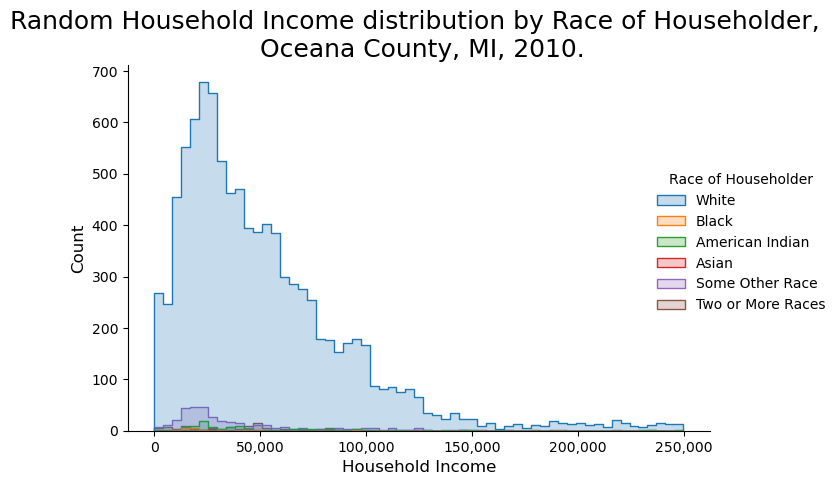

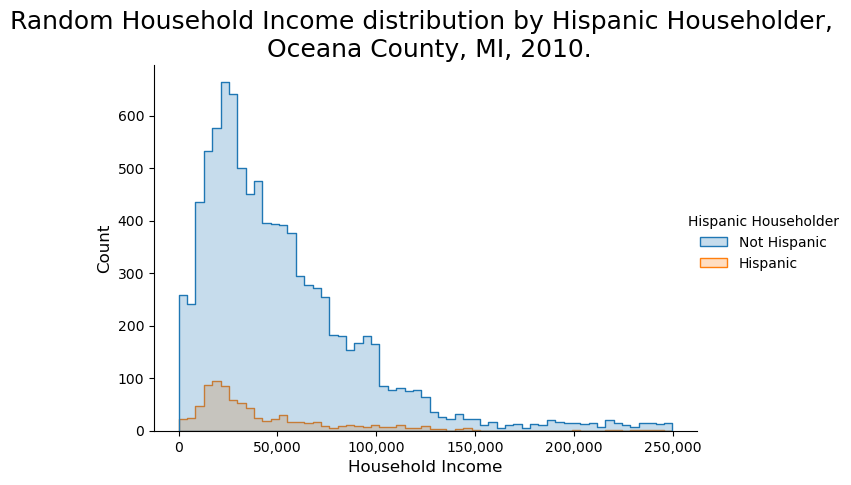

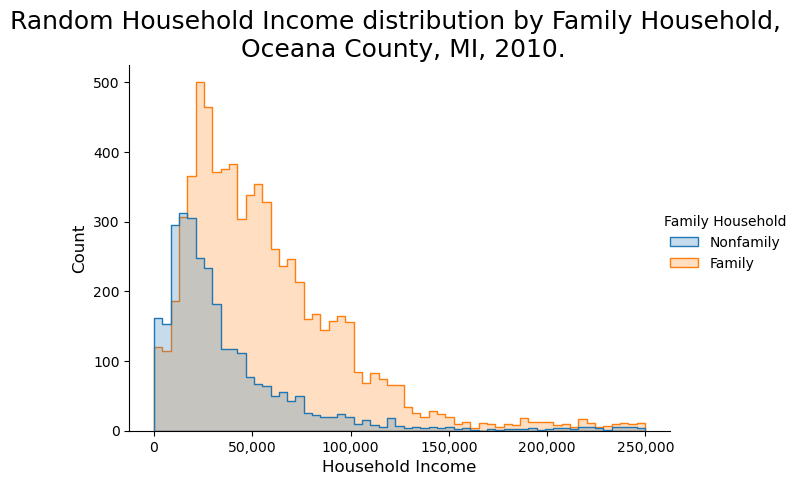

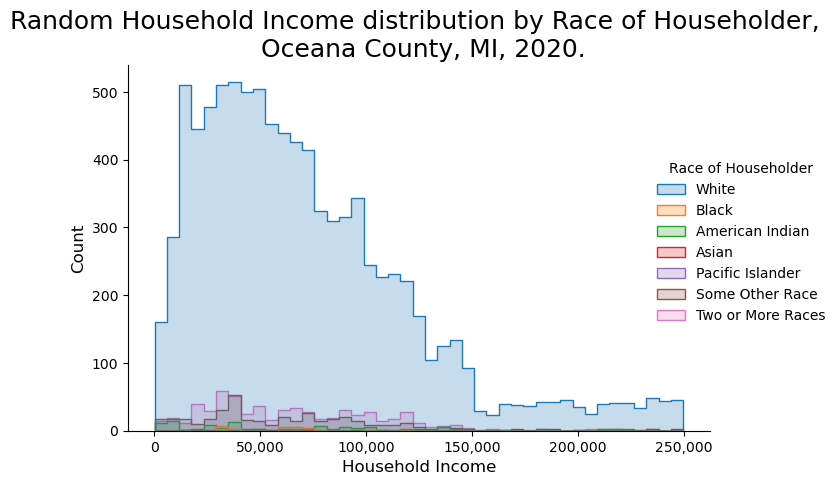

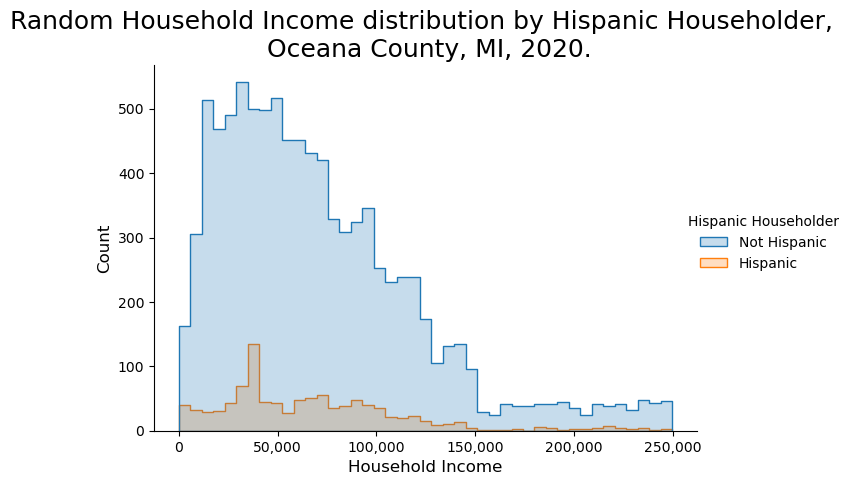

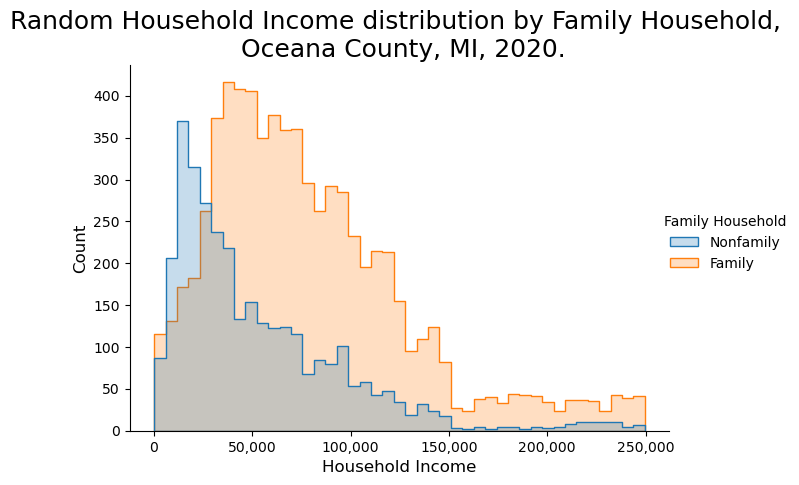

In [15]:
hua_hui_gdf_dict = {}
base_seed = 9876
iterations = 2
# iterate through basevintage options to run Monte Carlo Simulation
for basevintage in basevintage_options:
    hua_hui_gdf_dict[basevintage] = {}
    for i in range(iterations):
        seed_i = base_seed + i
        print(f"Running iteration {i+1} of {iterations} for basevintage {basevintage} with seed {seed_i}")
        workflow = process_community_workflow(
                    communities,
                    seed = seed_i,
                    version = '2.1.0',
                    version_text = 'v2-1-0',
                    basevintage = basevintage,
                    outputfolder ="OutputData",
                    outputfolders = {},
                    savefiles = True)
        hua_hui_gdf_dict[basevintage][seed_i] = workflow.process_communities()

## Run Person Record File

In [11]:
'''
CURRENT VERSION Person Record File only Works for 2010 Data

version = '3.0.0'
version_text = 'v3-0-0'

# open, read, and execute python program with reusable commands
from pyncoda.ncoda_07e_generate_prec import generate_prec_functions

# Save Outputfolder - due to long folder name paths output saved to folder with shorter name
# files from this program will be saved with the program name - 
# this helps to follow the overall workflow
outputfolder = "OutputData"
# Make directory to save output
if not os.path.exists(outputfolder):
    os.mkdir(outputfolder)

# Set random seed for reproducibility
seed = 1000
basevintage = 2010

generate_prec_df = generate_prec_functions(
                    communities =   communities,
                    seed =          seed,
                    version =       version,
                    version_text=   version_text,
                    basevintage=    basevintage,
                    outputfolder=   outputfolder
                    )

prec_df = generate_prec_df.generate_prec_v300()
'''

'\nCURRENT VERSION Person Record File only Works for 2010 Data\n\nversion = \'3.0.0\'\nversion_text = \'v3-0-0\'\n\n# open, read, and execute python program with reusable commands\nfrom pyncoda.ncoda_07e_generate_prec import generate_prec_functions\n\n# Save Outputfolder - due to long folder name paths output saved to folder with shorter name\n# files from this program will be saved with the program name - \n# this helps to follow the overall workflow\noutputfolder = "OutputData"\n# Make directory to save output\nif not os.path.exists(outputfolder):\n    os.mkdir(outputfolder)\n\n# Set random seed for reproducibility\nseed = 1000\nbasevintage = 2010\n\ngenerate_prec_df = generate_prec_functions(\n                    communities =   communities,\n                    seed =          seed,\n                    version =       version,\n                    version_text=   version_text,\n                    basevintage=    basevintage,\n                    outputfolder=   outputfolder\n    

## Explore and Validate Housing Unit Allocation


### Look at population characteristics and compare to US Census

In [16]:
where = communities[community_id]['community_name']
print(where, focalplace, countyname, countyfips)

Pentwater, MI Pentwater Oceana County, MI 26127


In [17]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","18,572 (89.1%)","3,703 (71.8%)","22,275 (85.6%)"
"2 Black alone, Not Hispanic",16 (0.1%),54 (1.0%),70 (0.3%)
"3 American Indian and Alaska Native alone, Not Hispanic",182 (0.9%),59 (1.1%),241 (0.9%)
"4 Asian alone, Not Hispanic",9 (0.0%),17 (0.3%),26 (0.1%)
"5 Other Race, Not Hispanic",175 (0.8%),48 (0.9%),223 (0.9%)
"6 Any Race, Hispanic","1,898 (9.1%)","1,275 (24.7%)","3,173 (12.2%)"
Total,"20,852 (100.0%)","5,156 (100.0%)","26,008 (100.0%)"


### Different Seeds have slightly different results
Notice that looking at a different seed the race, ethnicity, and tenure values are almost identical. For larger counties there may be small changes.

In [18]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'][9877], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","18,572 (89.1%)","3,703 (71.8%)","22,275 (85.6%)"
"2 Black alone, Not Hispanic",16 (0.1%),54 (1.0%),70 (0.3%)
"3 American Indian and Alaska Native alone, Not Hispanic",182 (0.9%),59 (1.1%),241 (0.9%)
"4 Asian alone, Not Hispanic",9 (0.0%),17 (0.3%),26 (0.1%)
"5 Other Race, Not Hispanic",175 (0.8%),48 (0.9%),223 (0.9%)
"6 Any Race, Hispanic","1,898 (9.1%)","1,275 (24.7%)","3,173 (12.2%)"
Total,"20,852 (100.0%)","5,156 (100.0%)","26,008 (100.0%)"


In [19]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2010'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","22,275 (97.5%)",nan (nan%),"22,275 (85.6%)"
"2 Black alone, Not Hispanic",70 (0.3%),nan (nan%),70 (0.3%)
"3 American Indian and Alaska Native alone, Not Hispanic",241 (1.1%),nan (nan%),241 (0.9%)
"4 Asian alone, Not Hispanic",26 (0.1%),nan (nan%),26 (0.1%)
"5 Other Race, Not Hispanic",223 (1.0%),nan (nan%),223 (0.9%)
"6 Any Race, Hispanic",nan (nan%),"3,173 (100.0%)","3,173 (12.2%)"
Total,"22,835 (100.0%)","3,173 (100.0%)","26,008 (100.0%)"


In [20]:
PopResultsTable.pop_results_table(
                  input_df = hua_hui_gdf_dict['2020'][9876], 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Hispanic')

Hispanic,0. Not Hispanic or Latino (%),1. Hispanic or Latino (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","21,241 (94.8%)",nan (nan%),"21,241 (81.7%)"
"2 Black alone, Not Hispanic",107 (0.5%),nan (nan%),107 (0.4%)
"3 American Indian and Alaska Native alone, Not Hispanic",177 (0.8%),nan (nan%),177 (0.7%)
"4 Asian alone, Not Hispanic",46 (0.2%),nan (nan%),46 (0.2%)
"5 Other Race, Not Hispanic",837 (3.7%),nan (nan%),837 (3.2%)
"6 Any Race, Hispanic",nan (nan%),"3,586 (100.0%)","3,586 (13.8%)"
Total,"22,408 (100.0%)","3,586 (100.0%)","25,994 (100.0%)"


In [21]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2010'][9876], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$42,419","$35,556","$41,441"
"2 Black alone, Not Hispanic","$22,940","$31,522","$30,328"
"3 American Indian and Alaska Native alone, Not Hispanic","$38,674","$26,225","$36,603"
"4 Asian alone, Not Hispanic","$55,411","$81,142","$80,767"
"5 Other Race, Not Hispanic","$45,724","$46,341","$45,724"
"6 Any Race, Hispanic","$29,548","$28,480","$29,018"
Total,"$41,611","$34,001","$40,053"


### Different Seeds have slightly different results
There is more uncertainty in the income data. This is because the income assigned to each household is a random value within the 17 income groups. In general the values for the median income fall within the Margin of Error reported by the American Community Survey. The MOE increases for populations with small sample sizes.

In [22]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2010'][9877], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2010 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$42,264","$37,200","$41,429"
"2 Black alone, Not Hispanic","$18,328","$24,701","$19,435"
"3 American Indian and Alaska Native alone, Not Hispanic","$38,925","$77,951","$39,819"
"4 Asian alone, Not Hispanic","$33,565","$76,351","$75,488"
"5 Other Race, Not Hispanic","$47,113","$49,058","$47,489"
"6 Any Race, Hispanic","$28,886","$26,629","$28,090"
Total,"$41,539","$35,327","$40,238"


In [23]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'][9876], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$62,487","$53,897","$60,902"
"2 Black alone, Not Hispanic","$68,142","$62,666","$65,102"
"3 American Indian and Alaska Native alone, Not Hispanic","$53,953","$26,227","$42,460"
"4 Asian alone, Not Hispanic","$64,904","$66,376","$64,904"
"5 Other Race, Not Hispanic","$56,653","$53,940","$54,624"
"6 Any Race, Hispanic","$58,666","$58,263","$58,520"
Total,"$62,034","$54,115","$60,630"


In [25]:
PopResultsTable.pop_results_table(hua_hui_gdf_dict['2020'][9877], 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = where,
                  when = '2020 (9877)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$61,648","$56,374","$60,776"
"2 Black alone, Not Hispanic","$62,101","$66,961","$63,489"
"3 American Indian and Alaska Native alone, Not Hispanic","$44,834","$37,576","$39,328"
"4 Asian alone, Not Hispanic","$58,603","$48,916","$53,540"
"5 Other Race, Not Hispanic","$62,327","$53,548","$58,964"
"6 Any Race, Hispanic","$62,430","$53,479","$59,562"
Total,"$61,654","$56,021","$60,668"


#### Validate the Housing Unit Allocation has worked
Notice that the population count totals for the community
should match (pretty closely) data collected for the 2010 Decennial Census.
This can be confirmed by going to data.census.gov

In [26]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US26127&tid=DECENNIALSF12010.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US26127&tid=ACSDT5Y2012.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US26127&tid=ACSDT5Y2012.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US26127&tid=ACSDT5Y2012.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US26127&tid=ACSDT5Y2012.B19013I


Differences in the housing unit allocation and the Census count may be due to differences between political boundaries and the building inventory. See Rosenheim et al 2019 for more details.

The housing unit allocation, plus the building results will become the input for the social science models such as the population dislocation model.

## Explore Maps

In [27]:
focalplace

'Pentwater'

In [28]:
hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}


[-86.44361355580031, -86.41874558389803] [43.77026020836393, 43.79063124539386]
[-86.44413856197654, -86.41874558389803] [43.76934021165627, 43.79063124539386]


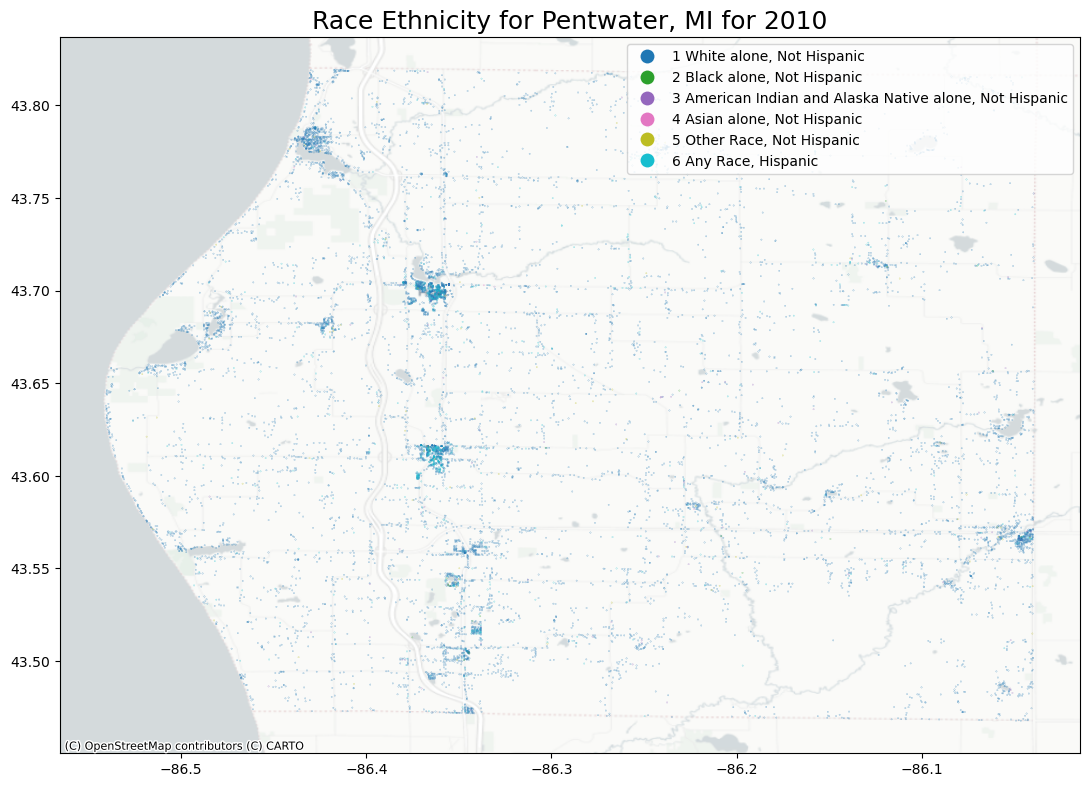

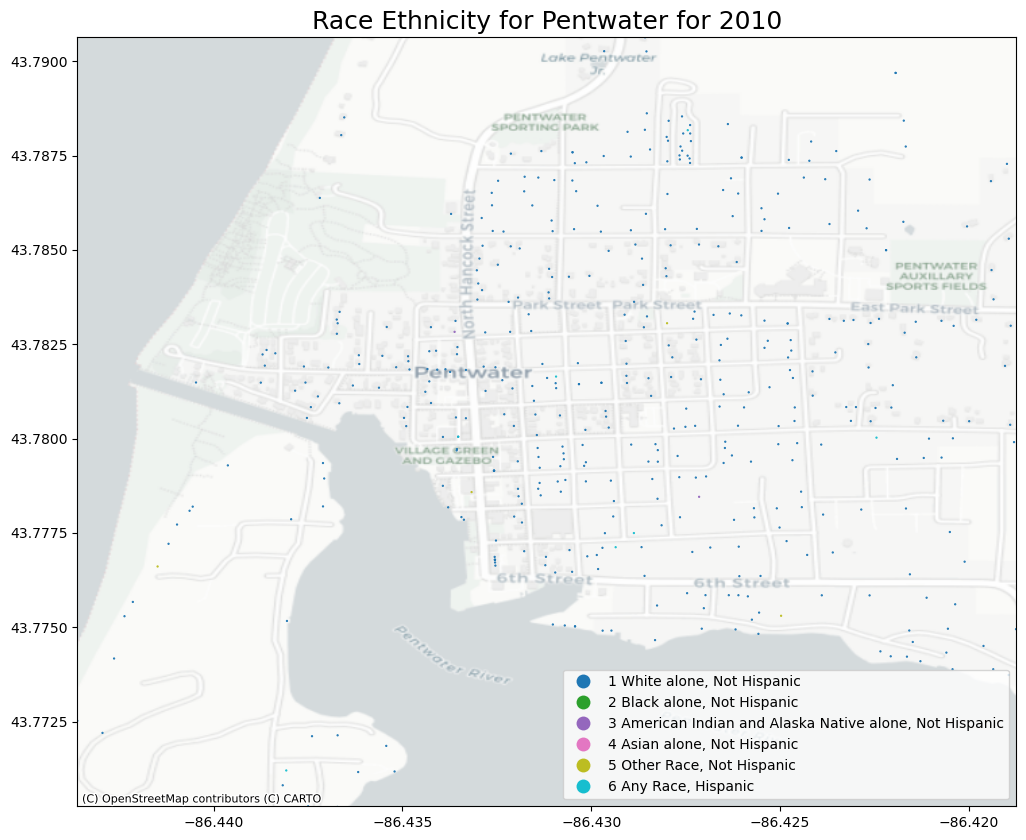

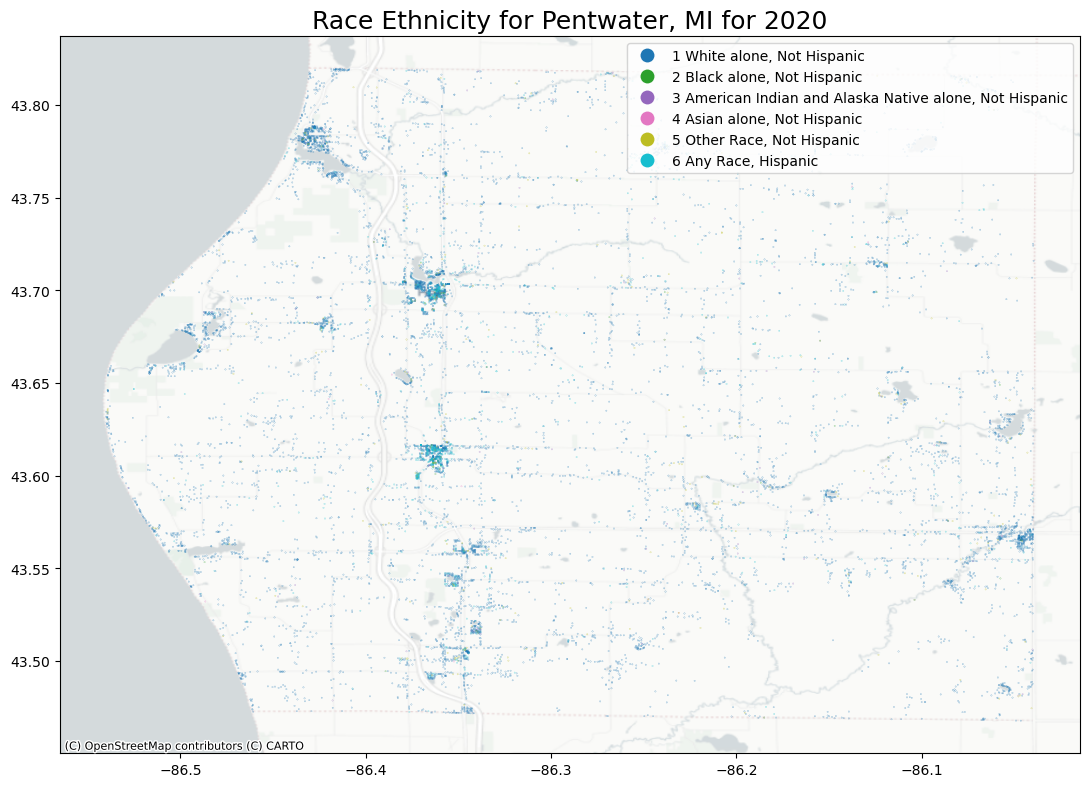

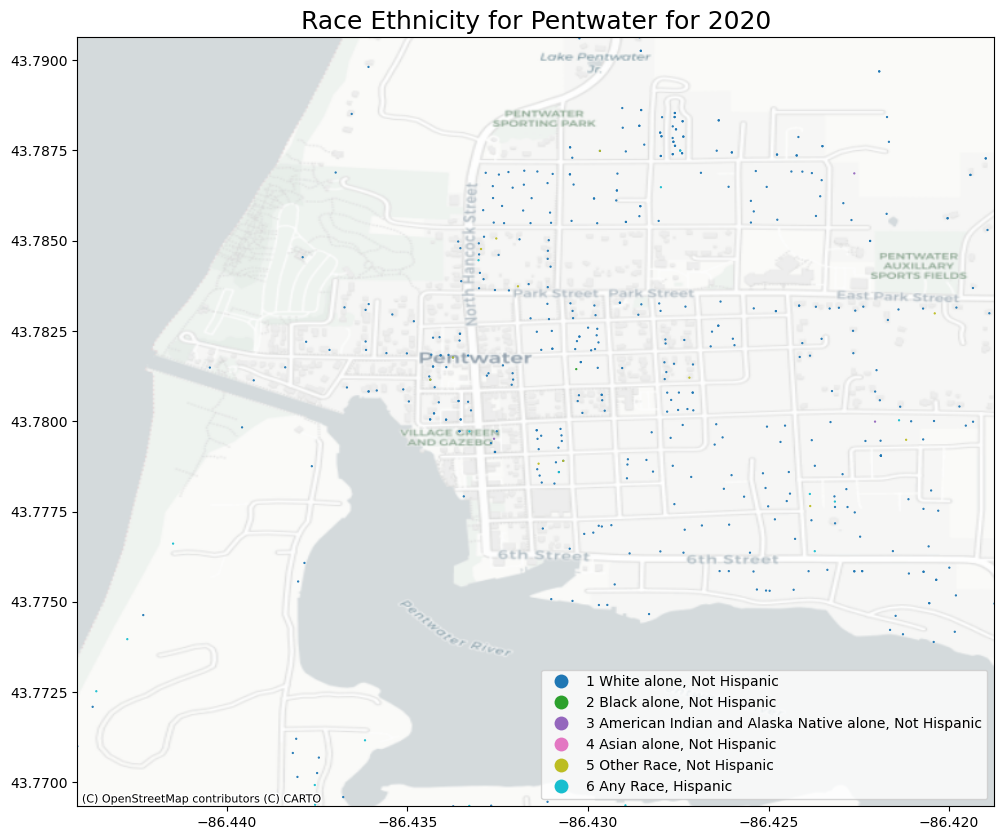

In [29]:
from pyncoda.ncoda_04b_foliummaps import *
# plot png file
from IPython.display import Image

seed_i = 9876

for year in ['2010','2020']:
    # add race ethnicity to data frame for better map legends
    hua_hui_race_gdf_dict[year] = PopResultsTable.add_race_ethnicity_to_pop_df(hua_hui_gdf_dict[year][seed_i])

    #mapname = 'hhincdotmap'
    mapname = f'hhracedotmap_{year}'
    # Map column
    #map_var = 'Household Income Group'
    map_var = 'Race Ethnicity'
    place = focalplace

    yr = str(year)[2:4]
    condition1 = "(hua_hui_race_gdf_dict[year].race >= 1)"
    condition2 = f"(hua_hui_race_gdf_dict[year].placeNAME{yr} == '{place}')"
    conditions = f"{condition1} & {condition2}"

    county_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(condition1)].copy(deep=True)
    county_hua_gdf_dict[year] = county_hua_gdf_dict[year].to_crs(epsg=4326)
    focal_place_hua_gdf_dict[year] = hua_hui_race_gdf_dict[year].loc[eval(conditions)].copy(deep=True)
    focal_place_hua_gdf_dict[year] = focal_place_hua_gdf_dict[year].to_crs(epsg=4326)

    bldg_inv_id = communities[community_id]['building_inventory']['id']
    outputfolder = 'OutputData'
    community = communities[community_id]['community_name']

    county_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                            mapname=mapname,
                            map_var=map_var,
                            bldg_inv_id=bldg_inv_id,
                            community=community_id,
                            place = community,
                            year = year,
                            outputfolder=outputfolder,
                            condition_id = "1",
                            basemap_source = cx.providers.CartoDB.Positron)
    
    # get xlim and ylim for focal place
    xlim = [focal_place_hua_gdf_dict[year].total_bounds[0], focal_place_hua_gdf_dict[year].total_bounds[2]]
    ylim = [focal_place_hua_gdf_dict[year].total_bounds[1], focal_place_hua_gdf_dict[year].total_bounds[3]]
    print(xlim, ylim)

    focal_place_map = plot_dotmap_map(gdf=county_hua_gdf_dict[year],
                        mapname=mapname,
                        map_var=map_var,
                        bldg_inv_id=bldg_inv_id,
                        community=community_id,
                        place = focalplace,
                        year = year,
                        outputfolder=outputfolder,
                        condition_id = "2",
                        basemap_source = cx.providers.CartoDB.Positron,
                        xlim = xlim,
                        ylim = ylim,
                        focal_gdf = focal_place_hua_gdf_dict[year])

In [36]:
# convert county name to string with _ instead of spaces
filename = "Oceana_MI"

In [37]:
# Make an animated GIF from the PNG images
from PIL import Image

# File paths for the PNG images
image1 = f'OutputData/{filename}/06_Explore/hhracedotmap_2010_{filename}_1_NSI.png'
image2 = f'OutputData/{filename}/06_Explore/hhracedotmap_2020_{filename}_1_NSI.png'
png_files = [image1, image2]

# Open the images
images = [Image.open(png) for png in png_files]

# Save as an animated GIF
output_gif = f'OutputData/{filename}_animated_map.gif'
images[0].save(
    output_gif,
    save_all=True,
    append_images=images[1:],  # Add the other images
    duration=1000,  # Duration for each frame in milliseconds
    loop=0  # Loop forever (set to 1 for a single loop)
)

## View Codebook
The Housing Unit Allocation methodology generates a codebook for the housing unit inventory.

Look in the OutputData folder to find the codebook.